In [1]:
# Importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
# Read the home prices data into a pandas dataframe
df = pd.read_csv("homeprices.csv")
df.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


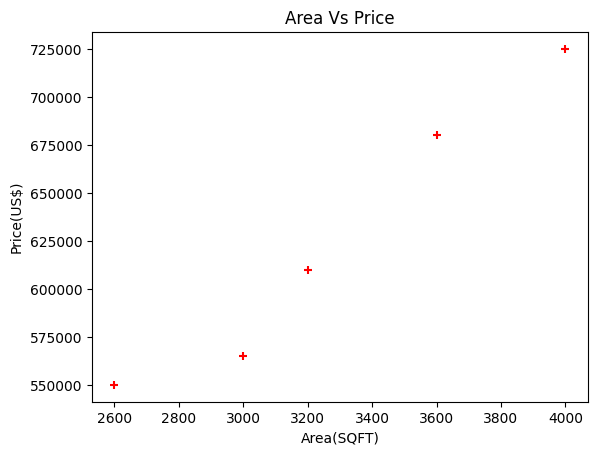

In [3]:
%matplotlib inline
plt.xlabel("Area(SQFT)")
plt.ylabel("Price(US$)")
plt.title("Area Vs Price")
plt.scatter(df.area, df.price, color="red", marker="+")

In [6]:
model = linear_model.LinearRegression()
# training the model
model.fit(df[["area"]], df.price)

LinearRegression()

In [10]:
print(model.coef_) # Slope
print(model.intercept_) # c 

[135.78767123]
180616.43835616432


In [13]:
model.predict([[5000]])

/home/kamrul/Desktop/python-ws/machine_learning/venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])

In [14]:
# load the area to predict prices
areas = pd.read_csv("areas.csv")
areas.head()

,area
0,1000
1,1500
2,2300
3,3540
4,4120


In [15]:
prices = model.predict(areas)
prices

array([ 316404.10958904,  384297.94520548,  492928.08219178,
        661304.79452055,  740061.64383562,  799808.21917808,
        926090.75342466,  650441.78082192,  825607.87671233,
        492928.08219178, 1402705.47945205, 1348390.4109589 ,
       1144708.90410959])

In [17]:
areas["prices"] = prices

In [18]:
areas

,area,prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [20]:
areas.to_csv("predicted_price", index=False)

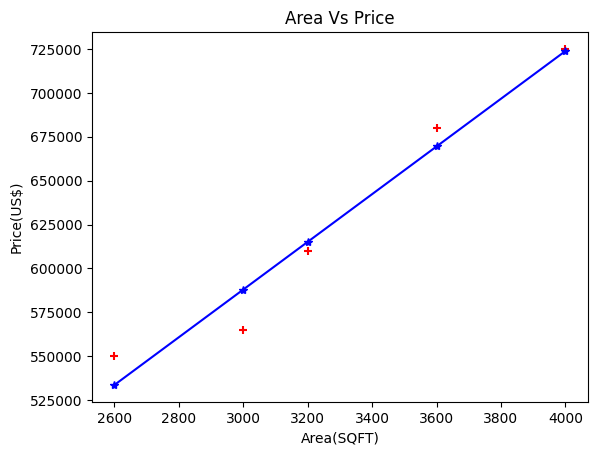

In [22]:
%matplotlib inline
plt.xlabel("Area(SQFT)")
plt.ylabel("Price(US$)")
plt.title("Area Vs Price")
plt.scatter(df.area, df.price, color="red", marker="+")
plt.plot(df.area, model.predict(df[["area"]]), color="blue", marker="*")